In [1]:
import numpy as np
import pandas as pd

In [2]:
import torch

data_path = "../data/filtered_train_test_split/"

POSITIONS = 18

X_test_tensor, y_test_tensor, test_inputs, targets = {}, {}, {}, {}

for i in range(POSITIONS):
    X_test_tensor[i] = torch.load(f"{data_path}X_test_{i}.pt")
    y_test_tensor[i] = torch.load(f"{data_path}y_test_{i}.pt")
    test_inputs[i] = pd.read_pickle(f"{data_path}X_test_{i}.pkl").tolist()
    targets[i] = pd.read_pickle(f"{data_path}y_test_{i}.pkl").tolist()


print(X_test_tensor[0][:5])
print(y_test_tensor[0][:5])
print(test_inputs[0][:5])
print(targets[0][:5])

C:\Users\gurgel\AppData\Local\Temp\ipykernel_7348\2132876398.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  X_test_tensor[i] = torch.load(f"{data_path}X_test_{i}.pt")


tensor([[ 4.6000e+01, -2.1376e-01, -2.7302e-01, -2.0079e-01, -2.5825e-01,
         -2.2256e-01, -2.2331e-01, -2.6441e-01, -2.9630e-01, -3.0502e-01,
         -3.1973e-01, -3.3386e-01, -4.1456e-01, -7.1675e-01, -8.0627e-01,
         -9.0755e-01, -1.0729e+00, -1.0910e+00, -1.0705e+00, -1.1417e+00,
         -1.1264e+00, -1.0887e+00, -1.0940e+00, -1.0091e+00, -9.9629e-01,
         -9.2584e-01, -8.4365e-01, -9.1054e-01, -8.1281e-01, -7.9621e-01,
         -6.8563e-01, -6.5276e-01, -6.0489e-01, -6.4545e-01, -5.5362e-01,
         -5.5409e-01, -5.8791e-01, -5.9253e-01, -5.4771e-01, -1.1744e+00,
         -1.1432e+00],
        [ 1.0000e+01, -1.2046e+00, -1.1377e+00, -1.1721e+00, -1.0619e+00,
         -9.7694e-01, -9.8520e-01, -8.2514e-01, -7.6225e-01, -7.4898e-01,
         -6.0825e-01, -7.8904e-01, -7.1147e-01, -6.8148e-01, -5.9219e-01,
         -6.5168e-01, -5.0646e-01, -4.5720e-01, -3.8838e-01, -3.0352e-01,
          6.8895e-02,  2.3324e-01,  4.0634e-01,  5.7931e-01,  6.1750e-01,
          5.780

In [3]:
from torch.utils.data import DataLoader, TensorDataset

batch_size = 512
num_workers = 16
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

inputs, test_dataset, test_loader = {}, {}, {}

for i in range(POSITIONS):
    inputs[i] = X_test_tensor[i].shape[1]
    test_dataset[i] = TensorDataset(X_test_tensor[i], y_test_tensor[i])
    test_loader[i] = DataLoader(
        dataset=test_dataset[i],
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
    )

print(test_loader[0].dataset.tensors)

(tensor([[46.0000, -0.2138, -0.2730,  ..., -0.5477, -1.1744, -1.1432],
        [10.0000, -1.2046, -1.1377,  ...,  0.5050, -1.1571, -1.1429],
        [33.0000, -1.7444, -1.7738,  ...,  0.8641,  1.2261,  1.2260],
        ...,
        [35.0000,  1.3852,  1.5208,  ...,  1.7421, -1.1643, -1.1480],
        [56.0000, -0.8822, -0.9156,  ...,  0.6520, -1.1681, -1.1030],
        [43.0000, -0.1381, -0.1438,  ..., -0.2081, -1.1750, -1.1440]]), tensor([0, 0, 1,  ..., 0, 0, 0]))


In [4]:
from mlp import CsiNeuralNet

models_path = "mlp/"
net: dict[int, CsiNeuralNet] = {}
prediction, accuracy = {}, {}

for i in range(POSITIONS):
    state_file = f"{models_path}filtered_model_{i}.pth"
    net[i] = CsiNeuralNet(inputs[i], device, state_file, output_dim=2)

    print(f"Model {i} loaded from {state_file}")
    prediction[i], accuracy[i] = net[i].test_model(test_loader[i])

c:\Users\gurgel\Desktop\Personal\Projects\UFF\Mestrado\Telecom\HAR\csi\models\mlp.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(state_

Model 0 loaded from mlp/filtered_model_0.pth
Testing on device: cuda
Accuracy: 99.83%, In 8.50s
Model 1 loaded from mlp/filtered_model_1.pth
Testing on device: cuda
Accuracy: 99.25%, In 8.58s
Model 2 loaded from mlp/filtered_model_2.pth
Testing on device: cuda
Accuracy: 99.27%, In 8.27s
Model 3 loaded from mlp/filtered_model_3.pth
Testing on device: cuda
Accuracy: 98.12%, In 8.56s
Model 4 loaded from mlp/filtered_model_4.pth
Testing on device: cuda
Accuracy: 99.48%, In 8.53s
Model 5 loaded from mlp/filtered_model_5.pth
Testing on device: cuda
Accuracy: 99.46%, In 8.59s
Model 6 loaded from mlp/filtered_model_6.pth
Testing on device: cuda
Accuracy: 99.00%, In 8.56s
Model 7 loaded from mlp/filtered_model_7.pth
Testing on device: cuda
Accuracy: 98.93%, In 8.72s
Model 8 loaded from mlp/filtered_model_8.pth
Testing on device: cuda
Accuracy: 99.11%, In 8.96s
Model 9 loaded from mlp/filtered_model_9.pth
Testing on device: cuda
Accuracy: 99.02%, In 8.90s
Model 10 loaded from mlp/filtered_model_

In [12]:
targets_len = len(targets[0])
num_positions = POSITIONS

# Model accuracy
correct_predictions = 0

# Model accuracy per position
total_targets = [0] * num_positions
correct_pred = [0] * num_positions

# Model confidence per position
sum_probabilities = [0.0] * num_positions
sum_correct_probabilities = [0.0] * num_positions
sum_wrong_probabilities = [0.0] * num_positions
prediction_counts = [0] * num_positions
correct_counts = [0] * num_positions
wrong_counts = [0] * num_positions

# Model confidence per accuracy for all positions
num_bins = 101
total_bins = [0] * num_bins
total_correct_bins = [0] * num_bins
pos_bins = [[0] * num_bins for _ in range(num_positions)]
pos_correct_bins = [[0] * num_bins for _ in range(num_positions)]

# Target positions to predict
position_targets = [
    next(pos for pos in range(POSITIONS) if targets[pos][i] == True)
    for i in range(targets_len)
]


def ensemble_predict(idx: int) -> tuple[int, float]:
    """
    Returns the ensemble prediction and confidence for a given index of the test set.

    Args:
        idx (int): Index of the test set.

    Returns:
        tuple[int, float]: The ensemble prediction and confidence.
    """
    confidences = []

    for pos in range(POSITIONS):
        state = torch.tensor([test_inputs[pos][idx]], dtype=torch.float32).to(device)
        net[pos].to(device)
        probabilities = net[pos].get_position_probabilities(state)
        confidences.append(probabilities[1])

    normalized_confidences = [conf / sum(confidences) for conf in confidences]
    max_confidence = max(normalized_confidences)
    prediction = normalized_confidences.index(max_confidence)

    return prediction, max_confidence


print(position_targets)

[13, 10, 0, 1, 3, 11, 9, 16, 5, 17, 15, 2, 2, 13, 16, 17, 0, 16, 16, 13, 4, 17, 5, 12, 6, 9, 14, 1, 11, 8, 2, 10, 6, 7, 12, 17, 4, 2, 1, 7, 0, 7, 3, 9, 8, 8, 8, 12, 1, 8, 10, 11, 7, 4, 11, 6, 12, 1, 15, 17, 12, 0, 3, 3, 0, 17, 6, 3, 13, 2, 9, 2, 17, 15, 3, 8, 9, 5, 14, 5, 5, 1, 0, 1, 17, 3, 10, 17, 4, 15, 6, 2, 10, 4, 4, 15, 1, 1, 11, 11, 17, 16, 2, 10, 5, 5, 3, 12, 9, 10, 14, 5, 9, 17, 10, 6, 9, 4, 2, 16, 10, 2, 6, 1, 11, 17, 15, 5, 9, 13, 5, 3, 10, 10, 8, 3, 13, 10, 3, 15, 5, 10, 9, 1, 17, 0, 13, 7, 8, 11, 14, 7, 2, 15, 3, 4, 8, 12, 6, 8, 7, 0, 1, 10, 6, 16, 6, 2, 12, 15, 8, 12, 14, 8, 8, 14, 13, 8, 11, 11, 6, 15, 4, 14, 9, 12, 1, 7, 9, 7, 6, 6, 6, 1, 0, 16, 15, 16, 10, 12, 15, 0, 14, 1, 11, 5, 11, 3, 8, 4, 13, 4, 0, 4, 11, 11, 9, 3, 8, 16, 10, 2, 6, 3, 13, 13, 0, 4, 9, 17, 14, 10, 8, 9, 9, 6, 6, 3, 7, 16, 9, 13, 8, 2, 0, 9, 9, 0, 14, 6, 15, 15, 5, 2, 7, 8, 14, 11, 8, 11, 14, 0, 17, 0, 14, 0, 6, 16, 5, 10, 15, 4, 9, 16, 10, 14, 7, 7, 4, 5, 14, 17, 6, 1, 0, 7, 2, 9, 1, 8, 9, 10, 7, 17

In [14]:
for i in range(targets_len):
    prediction, confidence = ensemble_predict(i)

    total_targets[position_targets[i]] += 1

    sum_probabilities[prediction] += confidence
    prediction_counts[prediction] += 1

    bin_index = int(confidence * 100)
    total_bins[bin_index] += 1
    pos_bins[prediction][bin_index] += 1

    if prediction == position_targets[i]:
        correct_predictions += 1
        
        correct_pred[position_targets[i]] += 1

        sum_correct_probabilities[prediction] += confidence
        correct_counts[prediction] += 1

        total_correct_bins[bin_index] += 1
        pos_correct_bins[prediction][bin_index] += 1
    else:
        sum_wrong_probabilities[prediction] += confidence
        wrong_counts[prediction] += 1

accuracy = correct_predictions / targets_len
print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 87.26%


[0.9843186233694143, 0.951486347128189, 0.9403018496126114, 0.8199351197618095, 0.9636808179595465, 0.9671382521489972, 0.928090777147381, 0.9223580158159598, 0.9510674560459276, 0.9377492941334648, 0.9750336172120125, 0.9706632082643889, 0.9737989303851512, 0.9777070063694268, 0.8578494719486653, 0.53388812246896, 0.5032039871840512, 0.5609108998452355]


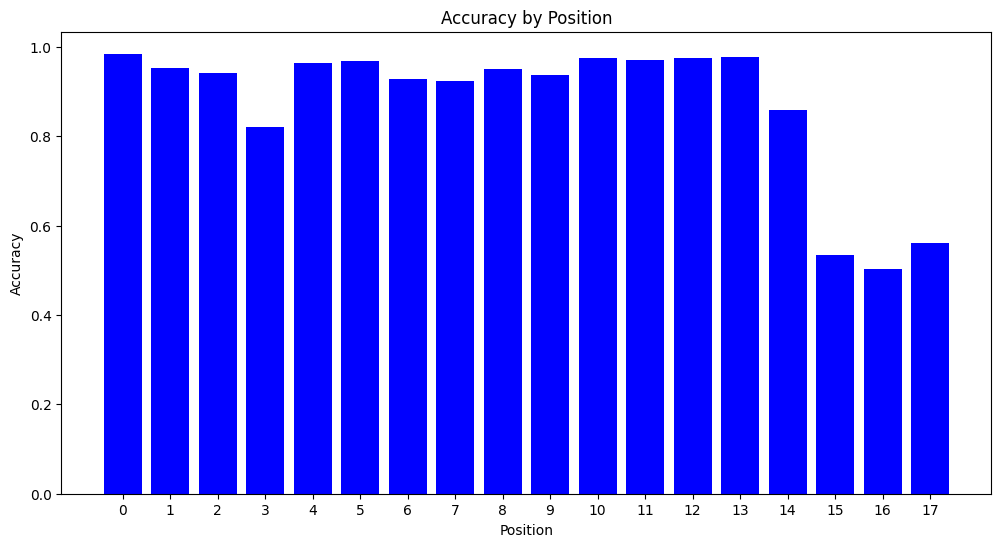

In [21]:
import matplotlib.pyplot as plt

positions = np.arange(num_positions)
accuracies = [correct_pred[i] / total_targets[i] for i in range(num_positions)]

print(accuracies)

plt.figure(figsize=(12, 6))
plt.bar(positions, accuracies, color="blue")
plt.xlabel("Position")
plt.ylabel("Accuracy")
plt.title("Accuracy by Position")
plt.xticks(positions)
plt.show()

In [16]:
average_total_probabilities = []
average_correct_probabilities = []
average_wrong_probabilities = []

for i in range(num_positions):
    average_total_probabilities.append(
        sum_probabilities[i] / prediction_counts[i] if prediction_counts[i] != 0 else 0
    )
    average_correct_probabilities.append(
        sum_correct_probabilities[i] / correct_counts[i]
        if correct_counts[i] != 0
        else 0
    )
    average_wrong_probabilities.append(
        sum_wrong_probabilities[i] / wrong_counts[i] if wrong_counts[i] != 0 else 0
    )

print(average_total_probabilities)
print(average_correct_probabilities)
print(average_wrong_probabilities)

[0.9814017048197173, 0.9276580791506165, 0.92838011408187, 0.84893374782658, 0.9497659092557721, 0.941235768666524, 0.8860634295071301, 0.8767923054407254, 0.8970311838876212, 0.8774953362210767, 0.9717977254546118, 0.9739959056657671, 0.9738247530431028, 0.9691845073302284, 0.898750582132525, 0.6679918296386538, 0.6654366986005992, 0.7342197606476824]
[0.9841141021831474, 0.9463037987255725, 0.946445466090973, 0.8875890708134518, 0.9601149044789612, 0.9572987018602455, 0.9115993106177352, 0.9031855810745244, 0.922843396214536, 0.9073631134973564, 0.9787155471581247, 0.9817400562328984, 0.9801881122815781, 0.9794830240993879, 0.9342409709221764, 0.7130287478930202, 0.7094600526457704, 0.7899818107046913]
[0.762776312787879, 0.6814347965743223, 0.6647941997085929, 0.6535819635398605, 0.7053808129068683, 0.6749337864326541, 0.6567620834663249, 0.6495267172651196, 0.6485754587890274, 0.6305757899038856, 0.7171727245805978, 0.6791068038069348, 0.71562013135909, 0.6813937765387107, 0.654567

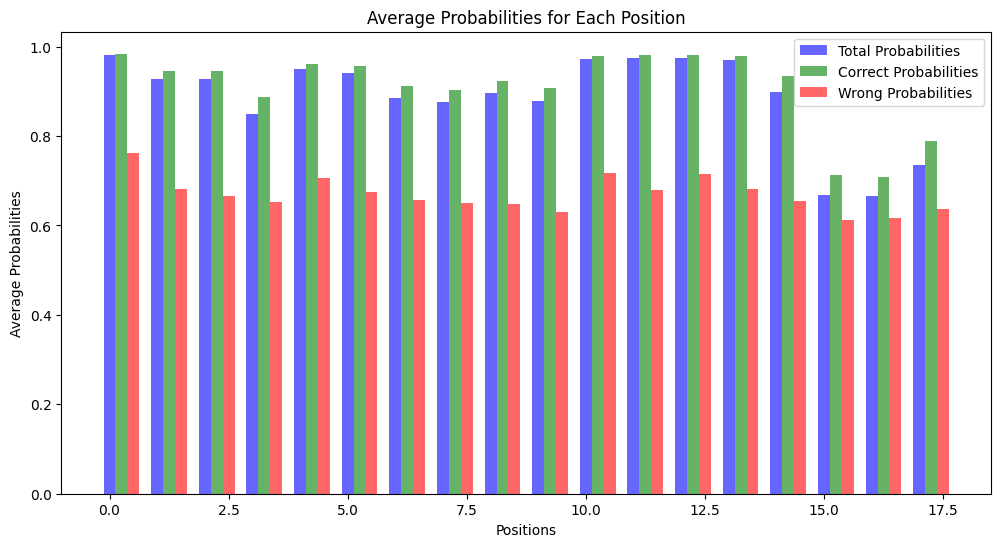

In [17]:
bar_width = 0.25

positions = np.arange(num_positions)
positions_total = positions
positions_correct = positions + bar_width
positions_wrong = positions + 2 * bar_width

plt.figure(figsize=(12, 6))
plt.bar(
    positions_total,
    average_total_probabilities,
    width=bar_width,
    color="blue",
    alpha=0.6,
    label="Total Probabilities",
)
plt.bar(
    positions_correct,
    average_correct_probabilities,
    width=bar_width,
    color="green",
    alpha=0.6,
    label="Correct Probabilities",
)
plt.bar(
    positions_wrong,
    average_wrong_probabilities,
    width=bar_width,
    color="red",
    alpha=0.6,
    label="Wrong Probabilities",
)
plt.xlabel("Positions")
plt.ylabel("Average Probabilities")
plt.title("Average Probabilities for Each Position")
plt.legend()
plt.show()

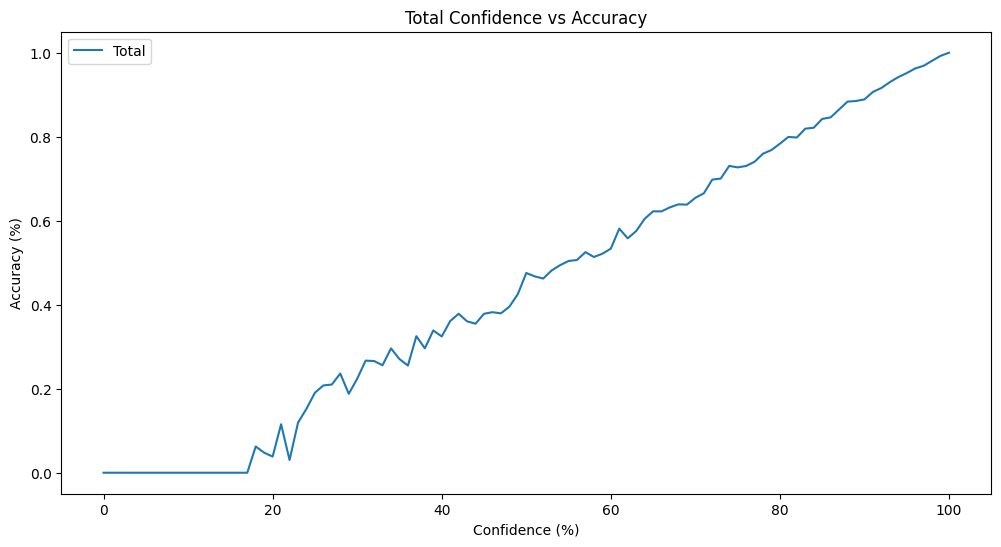

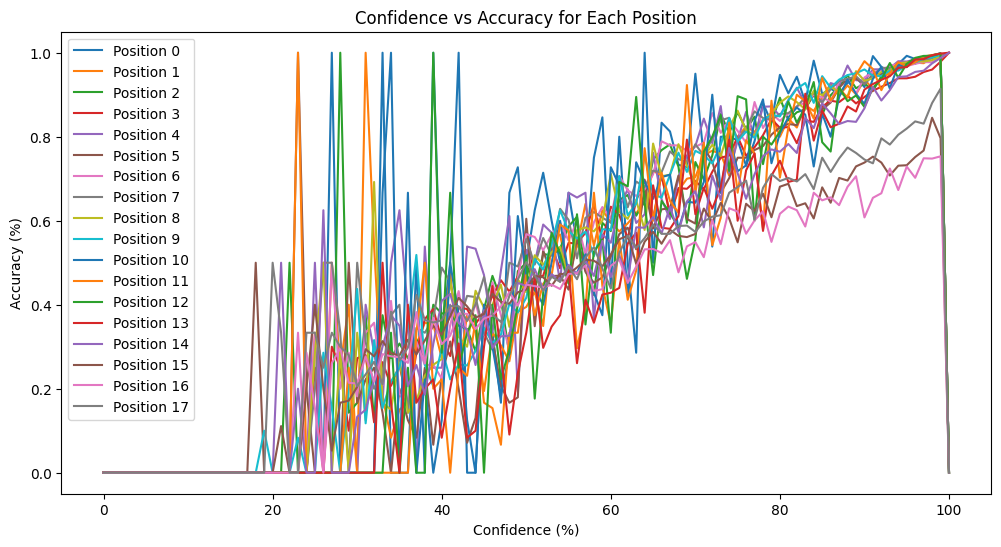

In [18]:
total_accuracy_bins = [0] * num_bins
pos_accuracy_bins = [[0] * num_bins for _ in range(num_positions)]

for i in range(num_bins):
    total_accuracy_bins[i] = (
        total_correct_bins[i] / total_bins[i] if total_bins[i] != 0 else 0
    )
    for j in range(num_positions):
        pos_accuracy_bins[j][i] = (
            pos_correct_bins[j][i] / pos_bins[j][i] if pos_bins[j][i] != 0 else 0
        )

# Plot the total confidence/accuracy relation
plt.figure(figsize=(12, 6))
plt.plot(range(num_bins), total_accuracy_bins, label="Total")
plt.xlabel("Confidence (%)")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.title("Total Confidence vs Accuracy")
plt.show()

# Plot the confidence/accuracy relation for each individual position
plt.figure(figsize=(12, 6))
for pos in range(num_positions):
    plt.plot(range(num_bins), pos_accuracy_bins[pos], label=f"Position {pos}")
plt.xlabel("Confidence (%)")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.title("Confidence vs Accuracy for Each Position")
plt.show()